# Векторный поиск и индексирование

В предыдущей работе мы научились представлять документы в виде эмбеддингов и выполнять семантический поиск. Для этого достаточно было вычислить эмбеддинг запроса, сравнить его с эмбеддингами всех документов и выбрать наиболее похожие.

Такой подход хорошо подходит для небольших коллекций текстов. Однако современные поисковые системы, рекомендательные сервисы и RAG-приложения должны обрабатывать большие коллекции документов и отвечать на запросы практически мгновенно. Поэтому возникает вопрос: можно ли ускорить такой поиск, не сравнивая запрос со всей коллекцией?

Чтобы ответить на этот вопрос, сначала рассмотрим самый простой способ поиска ближайших документов — полный перебор.

### Полный перебор

Пусть имеется коллекция из **N** документов. Для каждого документа заранее вычислен эмбеддинг размерности **d**. Для нового запроса также вычисляется эмбеддинг, после чего необходимо найти **k** наиболее похожих документов.

Самое очевидное решение — вычислить сходство запроса со всеми эмбеддингами коллекции и выбрать `k` наиболее похожих документов.

Если вычисление сходства между двумя эмбеддингами требует `O(d)` операций, то для коллекции из `N` документов полный перебор имеет сложность `O(N · d)`.

Размерность эмбеддинга фиксирована, поэтому основная зависимость от размера коллекции линейная — `O(N)`.

Но в этом алгоритме есть две разные задачи:

1. вычислить расстояние от запроса до всех документов;
2. выбрать среди найденных кандидатов `k` ближайших.

Очередь с приоритетами (`heap`) позволяет эффективно поддерживать `k` лучших результатов по мере обработки кандидатов. Вместо полной сортировки всех расстояний можно хранить только текущие `k` наиболее близких объектов. Однако `heap` не решает главную проблему полного перебора: чтобы понять, какие объекты являются кандидатами на попадание в `top-k`, нам всё равно приходится вычислять расстояние до каждого вектора.

Таким образом, `heap` помогает эффективно выбрать `k` лучших результатов, но не избавляет от главной особенности полного перебора: расстояние всё равно приходится вычислять для каждого вектора коллекции.

Значит, если мы хотим существенно ускорить поиск, нужно искать способ заранее сократить множество объектов, для которых вообще потребуется вычислять сходство.

### Как ускорить поиск?

Попробуем использовать структуры данных, которые позволяют заранее организовать коллекцию и не рассматривать все объекты одинаково.

На первый взгляд здесь подходят несколько знакомых нам идей:

- **деревья** — разбить пространство на области и искать только там, где может находиться ближайший сосед;
- **хеш-таблицы** — быстро находить объекты, попавшие в один `bucket`;
- **кластеризация** — разделить объекты на группы и сначала определить наиболее подходящие группы;
- **графы** — связать близкие объекты и использовать эти связи для навигации по коллекции.

Однако каждая из этих идей требует адаптации. Посмотрим, что из неё получится для поиска ближайших соседей.

### Деревья

Начнём с деревьев. Для поиска ближайших объектов в многомерном пространстве существуют специальные структуры данных, например KD-tree и Ball-tree.

**KD-tree** рекурсивно разбивает пространство по отдельным координатам. На каждом уровне выбирается одна координата, по которой пространство разделяется на области.

**Ball-tree** организует объекты в иерархию вложенных областей, каждая из которых описывается центром и радиусом. При поиске можно целиком исключать области, которые заведомо не содержат ближайших соседей.

Обе структуры позволяют не проверять каждый объект коллекции, а отбрасывать целые области пространства.

#### Как KD-tree сокращает область поиска?

Рассмотрим пример с точками в пространстве небольшой размерности. Если запрос находится в некоторой области, KD-tree позволяет исключить части пространства, которые заведомо не содержат ближайшего соседа.

В одномерном случае это просто отрезки числовой оси.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KDTree
from sklearn.metrics import pairwise_distances_argmin_min

rng = np.random.default_rng(42)

In [3]:
X = rng.random((30, 1))
query = np.array([[0.52]])

tree = KDTree(X)
distance, index = tree.query(query, k=1)
X[index[0]], distance[0]

(array([[0.55458479]]), array([0.03458479]))

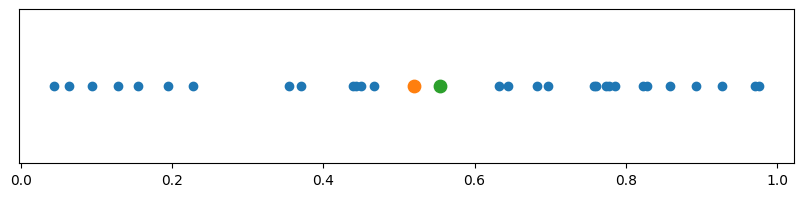

In [4]:
plt.figure(figsize=(10, 2))
plt.scatter(X[:, 0], np.zeros(len(X)))
plt.scatter(query[:, 0], 0, s=80)
plt.scatter(X[index[0], 0], 0, s=80)

plt.yticks([])
plt.show()

В двумерном случае KD-tree поочерёдно выбирает одну из координат и разделяет пространство по медиане. На следующем уровне используется другая координата, затем снова первая и так далее.

Для наглядности изобразим несколько первых уровней такого разбиения.

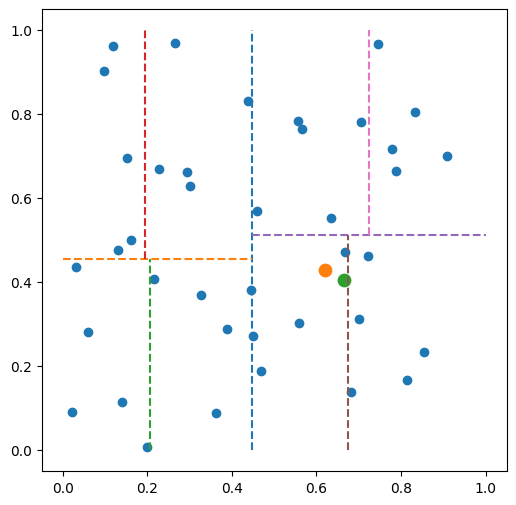

In [5]:
X = rng.random((40, 2))
query = np.array([[0.62, 0.43]])

tree = KDTree(X)
distance, index = tree.query(query, k=1)


def plot_splits(X, bounds, depth=0, max_depth=3):
    if len(X) == 0 or depth == max_depth:
        return

    axis = depth % 2
    median = np.median(X[:, axis])

    xmin, xmax, ymin, ymax = bounds

    if axis == 0:
        plt.plot([median, median], [ymin, ymax], linestyle="--")
        left = X[X[:, 0] <= median]
        right = X[X[:, 0] > median]

        plot_splits(left, [xmin, median, ymin, ymax], depth + 1, max_depth)
        plot_splits(right, [median, xmax, ymin, ymax], depth + 1, max_depth)

    else:
        plt.plot([xmin, xmax], [median, median], linestyle="--")
        lower = X[X[:, 1] <= median]
        upper = X[X[:, 1] > median]

        plot_splits(lower, [xmin, xmax, ymin, median], depth + 1, max_depth)
        plot_splits(upper, [xmin, xmax, median, ymax], depth + 1, max_depth)


plt.figure(figsize=(6, 6))

plt.scatter(X[:, 0], X[:, 1])
plt.scatter(query[0, 0], query[0, 1], s=80)
plt.scatter(X[index[0], 0], X[index[0], 1], s=80)

plot_splits(X, [0, 1, 0, 1])

plt.show()

Каждое следующее разбиение происходит внутри одной из уже полученных областей и использует другую координату. В результате пространство рекурсивно делится на всё более мелкие области.

При поиске ближайшего соседа дерево сначала рассматривает область, содержащую запрос, а затем проверяет, могут ли соседние области содержать более близкий объект. Если область заведомо находится дальше уже найденного соседа, её можно исключить из поиска.

Таким образом, преимущество KD-tree состоит не в том, что расстояния вычисляются быстрее, а в том, что благодаря разбиению пространства можно не вычислять расстояния до объектов в заведомо неподходящих областях.

В одномерном и двумерном пространствах такие разбиения легко представить геометрически. В трёхмерном пространстве они уже становятся менее наглядными, а при сотнях измерений визуализация пространства напрямую практически невозможна.

Поэтому для высокой размерности будем сравнивать не геометрию, а измеряемые характеристики поиска.

#### Что происходит при увеличении размерности?

Проверим, как меняется преимущество KD-tree при увеличении размерности пространства.

Для каждой размерности сравним два варианта поиска ближайшего соседа:

- полный перебор;
- KD-tree.

Размер коллекции и количество запросов оставим одинаковыми и будем изменять только размерность векторов.

Чтобы эксперимент соответствовал задаче поиска по эмбеддингам, нормализуем векторы. Для нормированных векторов поиск ближайшего соседа по евклидову расстоянию эквивалентен поиску по косинусному сходству. Время построения KD-tree в этот эксперимент не включаем: индекс строится один раз, после чего может использоваться для большого числа запросов. Нас интересует именно время выполнения самого поиска.

In [6]:
import time

from sklearn.preprocessing import normalize

n_documents = 10_000
n_queries = 500
dimensions = [1, 2, 3, 5, 10, 20, 50, 100, 384]
# Размерность `384` выбрана не случайно: именно столько координат содержит
# эмбеддинг модели `all-MiniLM-L6-v2`, использованной в предыдущей работе.

results = []

for d in dimensions:
    X = normalize(rng.random((n_documents, d)))
    queries = normalize(rng.random((n_queries, d)))

    start = time.perf_counter()
    pairwise_distances_argmin_min(queries, X)
    brute_time = time.perf_counter() - start

    tree = KDTree(X)

    start = time.perf_counter()
    tree.query(queries, k=1)
    tree_time = time.perf_counter() - start

    results.append({
        "Dimension": d,
        "Brute force, s": brute_time,
        "KD-tree, s": tree_time,
        "Speedup": brute_time / tree_time,
    })

results = pd.DataFrame(results)
results.round(3)

,Dimension,"Brute force, s","KD-tree, s",Speedup
0,1,0.045,0.042,1.058
1,2,0.022,0.001,18.627
2,3,0.022,0.001,16.287
3,5,0.023,0.003,7.459
4,10,0.025,0.029,0.876
5,20,0.028,0.356,0.079
6,50,0.070,0.493,0.141
7,100,0.054,2.526,0.022
8,384,0.471,9.705,0.048


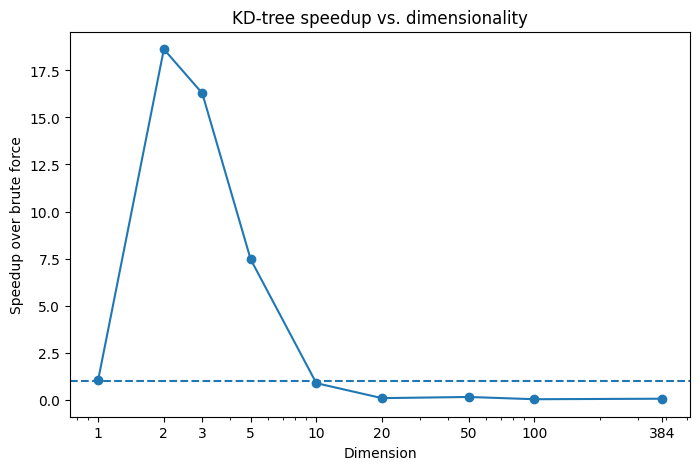

In [7]:
results.plot(
    x="Dimension",
    y="Speedup",
    marker="o",
    logx=True,
    xlabel="Dimension",
    ylabel="Speedup over brute force",
    title="KD-tree speedup vs. dimensionality",
    legend=False,
    figsize=(8, 5),
)

plt.xticks(dimensions, dimensions)
plt.axhline(1, linestyle="--")
plt.show()

Полученные значения зависят от размера коллекции, количества запросов, реализации алгоритмов и параметров эксперимента, поэтому конкретные значения времени не являются универсальными.

Однако эксперимент показывает общую закономерность: по мере роста размерности преимущество KD-tree над полным перебором уменьшается. В некоторой области размерностей стоимость организации поиска уже не компенсирует возможность отбрасывать области пространства, и KD-tree может оказаться не быстрее, а даже медленнее полного перебора.

Именно это явление называют **проклятием размерности** (*Curse of Dimensionality*). В пространствах небольшой размерности геометрическая структура данных позволяет эффективно исключать области, которые не могут содержать ближайших соседей. При увеличении числа измерений такие области становится всё сложнее исключать, и всё большая часть коллекции остаётся кандидатами на проверку.

Для текстовых эмбеддингов проблема особенно заметна: например, модель `all-MiniLM-L6-v2`, которую мы использовали в предыдущей работе, представляет предложение в пространстве размерности 384. Классические пространственные структуры данных уже не дают здесь того преимущества, которое они могут давать в пространствах небольшой размерности.

### Хеширование

Следующая знакомая идея — хеш-таблица. В обычной хеш-таблице хеш-функция помогает быстро определить, где в структуре данных искать запись с заданным ключом.

Но обычная хеш-функция не ставит перед собой задачу сохранять близость объектов. Похожие объекты могут получить совершенно разные хеши, а одинаковый хеш ещё не означает, что объекты похожи.

Можно ли специально построить хеш-функцию так, чтобы близкие объекты с большей вероятностью попадали в один `bucket`?

### Locality-Sensitive Hashing

Именно эту идею реализует **Locality-Sensitive Hashing (LSH)**. В LSH используются специальные хеш-функции, для которых вероятность совпадения хешей зависит от близости объектов: близкие объекты должны сталкиваться чаще, чем далёкие.

Для векторов одна из простых идей состоит в использовании случайных гиперплоскостей. Выбираем случайное направление и определяем, по какую сторону от разделяющей гиперплоскости находится вектор. Получаем один бит:

- одна сторона → `0`;
- другая сторона → `1`.

Несколько таких битов образуют хеш-код, который определяет `bucket`.

Для нового запроса вычисляется такой же хеш-код. В первую очередь рассматриваются объекты из соответствующего `bucket`'а и, при необходимости, из нескольких связанных с ним `bucket`'ов. Затем среди полученных кандидатов вычисляются настоящие расстояния и выбираются наиболее близкие объекты.

Проблема в том, что близкие объекты не обязаны получить одинаковый хеш. Поэтому используют несколько независимых хеш-функций или несколько хеш-таблиц. Если два объекта действительно близки, это увеличивает вероятность того, что они окажутся вместе хотя бы в одной из таблиц.

Таким образом, LSH не гарантирует, что настоящий ближайший сосед попадёт в множество кандидатов. Если он не попал ни в один из рассмотренных `bucket`'ов, точный поиск среди кандидатов его уже не найдёт.

Чем больше таблиц и кандидатов мы рассматриваем, тем выше вероятность найти настоящих ближайших соседей, но тем больше памяти и вычислений требуется.

#### Компромисс между скоростью и точностью

LSH позволяет значительно сократить множество кандидатов, для которых вычисляется точное расстояние. Однако за это приходится платить: результат уже не гарантированно совпадает с результатом полного перебора.

Параметры LSH позволяют выбирать компромисс между скоростью поиска и вероятностью найти настоящих ближайших соседей. Более широкий поиск повышает вероятность получить точный результат, но требует больше вычислений.

### Кластеризация

Ещё один способ сократить область поиска — заранее разбить векторы на кластеры.

Идея проста: близкие векторы должны чаще попадать в одну группу. Для нового запроса сначала определяем, какие кластеры находятся ближе всего к нему, а затем ищем ближайшие документы только внутри выбранных кластеров.

Например, можно использовать `k-means`: алгоритм разбивает векторы на `k` групп и для каждой группы вычисляет центр — центроид.

#### Построение и использование индекса

При построении индекса `k-means` на каждой итерации сопоставляет объекты с центроидами, после чего пересчитывает центроиды. Поэтому при большой коллекции и высокой размерности построение кластеров может быть заметно дорогим.

Однако индекс строится не для одного запроса. Если коллекция меняется редко, затраты на построение можно выполнить один раз, а затем использовать готовые кластеры для большого количества запросов.

При поиске сначала сравниваем эмбеддинг запроса с центроидами кластеров. После этого выбираем один или несколько ближайших кластеров и выполняем более точный поиск только среди их объектов.

#### Приближённый поиск по кластерам

Приближённый поиск возникает из-за того, что мы не обязаны проверять все кластеры.

Если искать только внутри одного ближайшего кластера, настоящий ближайший сосед может оказаться в другом кластере и не попасть в результат. Поэтому можно проверять несколько ближайших кластеров.

Количество проверяемых кластеров позволяет управлять компромиссом между скоростью и качеством поиска: чем больше кластеров мы проверяем, тем больше объектов становится кандидатами, но тем выше вероятность найти настоящих ближайших соседей.

Такой подход лежит в основе **IVF (Inverted File Index)**. Вместо полного перебора коллекции индекс сначала определяет несколько подходящих кластеров, а затем выполняет поиск только среди объектов, относящихся к ним.

Параметр `nprobe` определяет, сколько кластеров будет проверено для одного запроса. Малое значение `nprobe` ускоряет поиск, но повышает вероятность пропустить ближайшего соседа; увеличение `nprobe` повышает качество поиска ценой дополнительных вычислений.

У кластерного подхода есть несколько ограничений:

- построение кластеров может быть дорогим;
- качество поиска зависит от того, насколько удачно векторы разделены на кластеры;
- ближайшие соседи запроса могут оказаться в разных кластерах;
- для повышения качества приходится увеличивать число проверяемых кластеров, а вместе с ним — число кандидатов.

Тем не менее кластеризация позволяет сильно сократить множество объектов, для которых вычисляется точное расстояние, и поэтому является одним из практических подходов к приближённому поиску.

### Графы

Ещё один класс подходов к приближённому поиску использует графовые структуры.

Вместо того чтобы делить пространство на области или распределять объекты по `bucket`'ам и кластерам, можно представить каждый вектор как вершину графа, а связи между вершинами использовать для навигации по коллекции.

Для такой задачи можно строить графы по-разному. Например:

- соединять каждый объект с несколькими его ближайшими соседями;
- ограничивать количество связей у каждой вершины;
- добавлять связи между объектами, которые находятся далеко друг от друга, чтобы облегчить переход между разными областями пространства;
- строить несколько уровней графа, оставляя на верхних уровнях только часть вершин;
- использовать разные правила выбора соседей и разные стратегии обхода графа.

От выбора этих правил зависит, насколько хорошо граф будет одновременно поддерживать два свойства: по нему должно быть легко быстро добраться до нужной области пространства и при этом не должно быть слишком много связей, которые придётся хранить и просматривать.

При поиске запрос сравнивается не со всеми вершинами сразу. Вместо этого алгоритм начинает с одной или нескольких стартовых вершин и перемещается по графу, выбирая перспективных соседей. Если структура графа удачна, такой обход позволяет быстро перейти от удалённой области пространства к области, где находятся близкие к запросу объекты.

Графовые индексы отличаются друг от друга способом построения графа и алгоритмом навигации по нему. Один из наиболее известных вариантов — **HNSW**, который использует иерархию графов для ускорения такого поиска.

#### Метод HNSW

Рассмотрим метод **HNSW** (**Hierarchical Navigable Small World**). Он представляет коллекцию векторов в виде многоуровневого графа. На нижнем уровне находятся все объекты коллекции. Для каждой вершины случайно выбирается её максимальный уровень: все вершины присутствуют на уровне 0, часть из них поднимается на уровень 1, ещё меньшая часть — на уровень 2 и так далее. Поэтому число вершин постепенно уменьшается при движении вверх, а количество уровней растёт примерно логарифмически с размером коллекции.

Важно, что случайными являются не сами объекты и не их координаты, а только их максимальные уровни. Верхний уровень поэтому представляет собой небольшое подмножество тех же объектов, которые находятся на нижних уровнях.

Вершины соединяются с ограниченным числом других вершин, выбранных с учётом расстояния между объектами. При этом верхний уровень не просто хранит часть рёбер нижнего: для каждого уровня формируется свой набор связей.

Так возникает иерархия графов разной плотности:

- нижний уровень содержит все объекты и локальные связи между ними;
- выше находится меньше объектов, а связи строятся уже между этими объектами;
- самые верхние уровни содержат небольшое число объектов и позволяют делать более дальние переходы.

Поиск начинается с некоторой точки входа на верхнем уровне. Алгоритм рассматривает соседние вершины и выбирает наиболее перспективных кандидатов, постепенно приближаясь к области, где находятся векторы, близкие к запросу. Затем он спускается на следующий уровень и продолжает поиск уже в более плотной сети.

Эту идею удобно сравнить со списком с пропусками (**skip list**). В нём верхние уровни позволяют быстро перепрыгивать через большие участки последовательности, а нижние используются для уточнения позиции. В HNSW похожую роль играют верхние уровни графа, только вместо линейного порядка объектов используется их близость в векторном пространстве.

Для наглядности рассмотрим упрощённую схему многоуровневого графа HNSW.

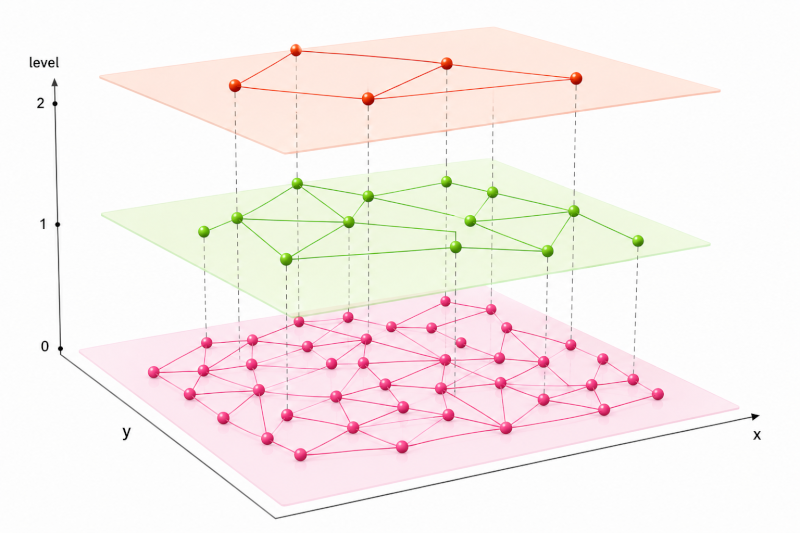

На схеме видно, как число вершин уменьшается при переходе на верхние уровни, а связи на каждом уровне образуют отдельный граф. Пунктирные линии показывают присутствие одной и той же вершины на нескольких уровнях.

При переходе на нижние уровни поиск становится шире: алгоритм рассматривает несколько кандидатов одновременно. Параметр `efSearch` ограничивает количество кандидатов, которые разрешено исследовать. Чем больше это значение, тем больше потенциальных соседей алгоритм проверяет и тем выше вероятность найти настоящих ближайших соседей, но тем больше времени занимает поиск.

Таким образом, HNSW не пытается, как KD-tree или Ball-tree, разбить пространство на области и доказать, что целые области можно исключить. Вместо этого он использует многоуровневый граф, чтобы быстро перейти в перспективную область пространства, а затем уточнить результат на более плотном уровне.

При этом HNSW не даёт гарантии, что найденный сосед является глобально ближайшим. Если поиск исследовал недостаточно кандидатов или навигация по графу привела в неудачную область, настоящий ближайший объект может остаться вне рассмотрения. Поэтому HNSW является приближённым методом.

### Приближённый поиск ближайших соседей

Мы рассмотрели несколько способов сократить множество кандидатов для поиска ближайших соседей. При этом они используют разные идеи и дают разные гарантии.

KD-tree и Ball-tree могут выполнять точный поиск: если структура позволяет доказать, что целая область не содержит более близкого объекта, её можно безопасно исключить. В LSH, IVF и HNSW множество кандидатов обычно сокращается без такой гарантии, поэтому настоящий ближайший сосед может остаться вне рассмотрения.

Поиск, в котором мы сознательно отказываемся от гарантии найти точных ближайших соседей ради ускорения, называют **приближённым поиском ближайших соседей — Approximate Nearest Neighbor (ANN)**.


#### Как работает приближённый поиск

Приближённый поиск использует структуру индекса и параметры поиска, чтобы быстро определить множество наиболее перспективных кандидатов, среди которых затем выбираются ближайшие объекты.

Чем меньше кандидатов приходится рассматривать, тем быстрее выполняется поиск. Однако при слишком агрессивном сокращении множества кандидатов возрастает вероятность не включить в него действительно ближайший объект.

Таким образом, приближённый поиск позволяет управлять компромиссом между **скоростью поиска и вероятностью получить точный результат**.

Чтобы формализовать эту идею, обозначим через `N` размер всей коллекции, а через `C` — количество кандидатов, которые рассматриваются при приближённом поиске. В хорошо настроенном индексе `C` может быть значительно меньше `N`.

При слишком сильном сокращении `C` возрастает вероятность, что настоящий ближайший сосед не попадёт в число кандидатов. В этом случае приближённый поиск вернёт результат, который отличается от результата точного поиска.

### Как измерить качество приближённого поиска

Для этого можем использовать точный поиск как эталон. Пусть точный алгоритм вернул `k` ближайших соседей, а ANN — свои `k` кандидатов.

**Recall@k** показывает, какая доля настоящих `k` ближайших соседей была найдена приближённым алгоритмом:

`Recall@k = количество совпавших объектов / k`

Например, если точный поиск вернул 5 ближайших документов, а ANN нашёл 4 из них, то `Recall@5 = 4 / 5 = 0.8`.

Таким образом, Recall@k позволяет отдельно оценивать качество приближённого поиска, не используя сам ANN для оценки его собственных результатов.

Recall@k учитывает только то, какие объекты попали в эталонный `top-k`, но не учитывает, насколько близко к ним находятся остальные найденные объекты. Например, объект, занявший в точном поиске `k+1` место, и совершенно нерелевантный объект для этой метрики одинаково считаются ненайденными.

Для нашего эксперимента этого достаточно, но при более подробной оценке качества поиска можно использовать метрики, учитывающие ранжирование результатов.

### Точный поиск как эталон

Чтобы оценивать качество приближённого поиска, нам нужен эталонный результат. Для небольшой коллекции его можно получить полным перебором: вычислить расстояние от запроса до каждого вектора и выбрать `k` ближайших.

Такой поиск может быть слишком дорогим для большой коллекции, но в эксперименте он позволяет получить точный ответ, с которым мы будем сравнивать результаты ANN.

### Коллекция документов

В качестве небольшой коллекции документов возьмём данные со **Stack Overflow**. Будем использовать вопросы, относящиеся к программированию, алгоритмам и машинному обучению. Дополнительно оставим теги `tree` и `xml`, чтобы поэкспериментировать с похожими словами в разных контекстах и, наоборот, с разными словами для близких понятий.

In [8]:
from bs4 import BeautifulSoup

def clean_html(text):
    return BeautifulSoup(text, "html.parser").get_text(" ", strip=True)

def load_documents(path, tags, questions_per_tag=100):
    path = Path(path)

    if path.exists():
        return pd.read_csv(path)

    questions = []

    for tag in tags:
        params = {
            "site": "stackoverflow",
            "tagged": tag,
            "pagesize": questions_per_tag,
            "page": 1,
            "order": "desc",
            "sort": "votes",
            "filter": "withbody",
        }

        response = requests.get(
            "https://api.stackexchange.com/2.3/questions",
            params=params,
        )
        response.raise_for_status()

        questions.extend(response.json()["items"])

    documents = pd.DataFrame(questions)

    documents["title"] = documents["title"].apply(clean_html)
    documents["body"] = documents["body"].apply(clean_html)
    documents["text"] = documents["title"] + " " + documents["body"]

    documents = documents[
        [
            "question_id",
            "title",
            "body",
            "tags",
            "score",
            "link",
            "text",
        ]
    ]

    documents = documents.drop_duplicates("question_id")
    documents.to_csv(path, index=False)

    return documents

In [9]:
from pathlib import Path

import requests

In [10]:
DATA_PATH = Path("data/documents.csv")

TAGS = [
    "python",
    "data-structures",
    "algorithm",
    "machine-learning",
    "xml",
    "tree",
]

### Подготовка коллекции документов

Загрузим коллекцию вопросов из файла `data/documents.csv`, если он существует, иначе загрузим вопросы через Stack Exchange API.

Для каждого вопроса используем заголовок и очищенный от HTML текст, объединённые в поле `text`.

In [11]:
documents = load_documents(DATA_PATH, TAGS)

print("Количество документов:", len(documents))
print("Столбцы:", documents.columns.tolist())

Количество документов: 580
Столбцы: ['question_id', 'title', 'body', 'tags', 'score', 'link', 'text']


In [12]:
documents[["title", "text"]].head(5)

,title,text
0,"What does the ""yield"" keyword do in Python?","What does the ""yield"" keyword do in Python? Wh..."
1,"What does if __name__ == ""__main__"": do?","What does if __name__ == ""__main__"": do? What ..."
2,Does Python have a ternary conditional operator?,Does Python have a ternary conditional operato...
3,What are metaclasses in Python?,What are metaclasses in Python? What are metac...
4,How do I check whether a file exists without e...,How do I check whether a file exists without e...


### Построение эмбеддингов

Преобразуем тексты документов в векторы с помощью модели `all-MiniLM-L6-v2`.

Полученные векторы будем использовать для поиска семантически близких документов.

In [13]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    documents["text"].tolist(),
    show_progress_bar=True,
)

print("Размер матрицы эмбеддингов:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Размер матрицы эмбеддингов: (580, 384)


Теперь каждый документ представлен точкой в 384-мерном пространстве. Выполним по этой коллекции точный поиск ближайших соседей и используем его как baseline для дальнейшего сравнения.

### Точный поиск ближайших соседей

Теперь у нас есть коллекция документов, представленных векторами. Для начала реализуем точный поиск: для заданного запроса будем вычислять его сходство с документами коллекции и выбирать наиболее близкие.

Этот вариант будем использовать как baseline для сравнения с приближённым поиском.

Рассмотрим один запрос и найдём для него `k = 5` ближайших соседей полным перебором.

In [14]:
k = 5

In [15]:
from sklearn.neighbors import NearestNeighbors

index = NearestNeighbors(
    n_neighbors=k,
    metric="cosine",
    algorithm="brute",
)

index.fit(embeddings)

NearestNeighbors(algorithm='brute', metric='cosine')

`NearestNeighbors` возвращает косинусное расстояние. Для вывода косинусного сходства используем `1 - distance`.

In [16]:
query = "How does a binary search tree work?"
query_embedding = model.encode([query])
distances, indices = index.kneighbors(query_embedding)

for distance, i in zip(distances[0], indices[0]):
    print(f"{1 - distance:.4f}  {documents['title'].iloc[i]}")

0.8224  Difference between binary tree and binary search tree
0.6188  Binary Search Tree - Java Implementation
0.6046  Advantages of Binary Search Trees over Hash Tables
0.5895  Non-recursive depth first search algorithm
0.5764  Difference between Tries and Trees?


В нашем эксперименте поиск выполняется не по всему Stack Overflow, а по небольшой коллекции вопросов, которую мы заранее загрузили в ноутбук. Это важно учитывать при интерпретации результатов: качество поиска в таком эксперименте зависит не только от модели эмбеддингов и алгоритма поиска, но и от состава коллекции.

Точный поиск действительно находит документы с максимальным косинусным сходством среди этой коллекции. Однако это не означает, что они обязательно будут наиболее релевантными с точки зрения человека: качество семантического соответствия зависит в том числе от самой модели эмбеддингов.

Полученные документы отсортированы по убыванию косинусного сходства с запросом. Насколько результаты соответствуют смыслу запроса?

### Поиск по нескольким запросам

Проверим точный поиск на нескольких запросах, относящихся к разным темам нашей коллекции.

In [17]:
queries = [
    "How does a binary search tree work?",
    "How can I parse XML in Python?",
    "How does gradient descent work?",
    "How can I find the shortest path in a graph?",
    "How do I implement a hash table in Python?",
    "What is the difference between a tree and a graph?",
    "How can I traverse a directory tree?",
    "How can I convert XML to JSON?",
    "How does a neural network learn?",
    "How do I find the nearest neighbor of a point?",
]

In [18]:
query_embeddings = model.encode(queries)

exact_distances, exact_indices = index.kneighbors(query_embeddings)

for query, query_distances, query_indices in zip(
    queries,
    exact_distances,
    exact_indices,
):
    print(f"\nQuery: {query}")

    for rank, (distance, i) in enumerate(
        zip(query_distances, query_indices),
        start=1,
    ):
        print(
            f"{rank}. {1 - distance:.4f}  "
            f"{documents['title'].iloc[i]}"
        )


Query: How does a binary search tree work?
1. 0.8224  Difference between binary tree and binary search tree
2. 0.6188  Binary Search Tree - Java Implementation
3. 0.6046  Advantages of Binary Search Trees over Hash Tables
4. 0.5895  Non-recursive depth first search algorithm
5. 0.5764  Difference between Tries and Trees?

Query: How can I parse XML in Python?
1. 0.7662  Python xml ElementTree from a string source?
2. 0.7453  Creating a simple XML file using python
3. 0.7390  Converting XML to JSON using Python?
4. 0.7366  Pretty printing XML in Python
5. 0.6247  How does one parse XML files?

Query: How does gradient descent work?
1. 0.6276  pytorch - connection between loss.backward() and optimizer.step()
2. 0.4601  What is the role of the bias in neural networks?
3. 0.4343  What is cross-entropy?
4. 0.4133  What is machine learning?
5. 0.3880  How should the learning rate change as the batch size change?

Query: How can I find the shortest path in a graph?
1. 0.3738  Construct a min

### Приближённый поиск с FAISS

Для практической части воспользуемся библиотекой **FAISS** ([faiss.ai](https://faiss.ai/)). Она предоставляет готовые структуры индексов для поиска ближайших соседей и позволяет использовать разные подходы к индексированию векторов.

В нашем эксперименте построим HNSW-индекс и сравним его результаты с точным поиском.

In [19]:
import faiss

#### Построение HNSW-индекса

Создадим в FAISS индекс HNSW для наших эмбеддингов.

Первый параметр `IndexHNSWFlat` — размерность векторов.

Второй параметр `M` задаёт максимальное число связей вершины с другими вершинами. Для `M` нет универсального значения: в документации FAISS рекомендуется ориентироваться примерно на диапазон от `4` до `64`. Большее значение позволяет построить более связный граф, но увеличивает объём памяти. В нашем небольшом эксперименте возьмём `M = 16`.

Параметр `efConstruction` определяет, насколько широко исследуется граф при добавлении объектов в индекс. Чем больше его значение, тем тщательнее можно выбрать связи, но тем больше времени требуется на построение. Универсального значения этого параметра нет. В документации и экспериментах FAISS встречается, например, `efConstruction = 200`; в нашем эксперименте также будем использовать это значение.

Параметр `efSearch` определяет глубину поиска по графу: чем больше его значение, тем больше кандидатов рассматривается при поиске. FAISS рекомендует настраивать `efSearch` как параметр компромисса между скоростью и качеством поиска. В одном из [примеров в документации FAISS](https://github.com/facebookresearch/faiss/wiki/Indexing-1M-vectors) для HNSW сравниваются значения `16`, `32`, `64`, `128` и `256`: при увеличении `efSearch` растут и время поиска, и `Recall@1`. В нашем небольшом эксперименте начнём со значения `efSearch = 16`.

Параметры HNSW относятся к разным этапам работы с индексом. `M` задаётся при создании индекса, `efConstruction` — до добавления объектов, а `efSearch` можно изменять непосредственно перед поиском без перестроения индекса.

Перед передачей в `FAISS` приведём векторы к типу `float32`, который используется индексами `FAISS`. Копию создадим, чтобы последующая нормализация не изменяла исходные эмбеддинги.

Для использования косинусного сходства нормализуем эмбеддинги. Для нормированных векторов внутреннее произведение совпадает с косинусным сходством, поэтому в качестве метрики используем `METRIC_INNER_PRODUCT`.

In [20]:
hnsw_embeddings = embeddings.astype("float32").copy()
faiss.normalize_L2(hnsw_embeddings)

dimension = hnsw_embeddings.shape[1]
M = 16

hnsw_index = faiss.IndexHNSWFlat(
    dimension,
    M,
    faiss.METRIC_INNER_PRODUCT,
)
hnsw_index.hnsw.efConstruction = 200
hnsw_index.hnsw.efSearch = 16

hnsw_index.add(hnsw_embeddings)

#### Поиск по HNSW-индексу

Подготовим эмбеддинги запросов так же, как эмбеддинги документов: приведём их к `float32` и нормализуем.

In [21]:
hnsw_queries = query_embeddings.astype("float32").copy()
faiss.normalize_L2(hnsw_queries)

Затем выполним поиск по HNSW-индексу. Второй аргумент `search` задаёт количество ближайших соседей, которые нужно вернуть. Возьмём наше `k = 5`, как и при точном поиске.

In [22]:
ann_distances, ann_indices = hnsw_index.search(
    hnsw_queries,
    k,
)

#### Результаты поиска

Выведем результаты HNSW в том же формате, что и результаты точного поиска. Это позволит сравнить найденные документы и значения сходства для одинаковых запросов.

In [23]:
for query, similarities, indices in zip(
    queries,
    ann_distances,
    ann_indices,
):
    print(f"\nQuery: {query}")

    for rank, (similarity, i) in enumerate(
        zip(similarities, indices),
        start=1,
    ):
        print(
            f"{rank}. {similarity:.4f}  "
            f"{documents['title'].iloc[i]}"
        )


Query: How does a binary search tree work?
1. 0.8224  Difference between binary tree and binary search tree
2. 0.6188  Binary Search Tree - Java Implementation
3. 0.6046  Advantages of Binary Search Trees over Hash Tables
4. 0.5895  Non-recursive depth first search algorithm
5. 0.5764  Difference between Tries and Trees?

Query: How can I parse XML in Python?
1. 0.7662  Python xml ElementTree from a string source?
2. 0.7453  Creating a simple XML file using python
3. 0.7390  Converting XML to JSON using Python?
4. 0.7366  Pretty printing XML in Python
5. 0.6247  How does one parse XML files?

Query: How does gradient descent work?
1. 0.6276  pytorch - connection between loss.backward() and optimizer.step()
2. 0.4601  What is the role of the bias in neural networks?
3. 0.4343  What is cross-entropy?
4. 0.4133  What is machine learning?
5. 0.3880  How should the learning rate change as the batch size change?

Query: How can I find the shortest path in a graph?
1. 0.3738  Construct a min

#### Оценка Recall@k

Сравним результаты HNSW с результатами точного поиска. Для каждого запроса точный поиск задаёт эталонные `k` ближайших объектов, а Recall@k показывает, какая доля этих объектов была найдена HNSW.

Поскольку в нашем эксперименте `k = 5`, для каждого запроса Recall@5 равен числу совпавших объектов, делённому на `5`.

Для общей оценки качества усредним Recall@5 по всем запросам.

In [24]:
def recall_at_k(exact_indices, ann_indices, k):
    exact_set = set(exact_indices[:k])
    ann_set = set(ann_indices[:k])
    return len(exact_set & ann_set) / k

In [25]:
recalls = [
    recall_at_k(exact, ann, k)
    for exact, ann in zip(exact_indices, ann_indices)
]

for query, recall in zip(queries, recalls):
    print(f"{recall:.2f}  {query}")

mean_recall = np.mean(recalls)
print(f"Mean Recall@{k}: {mean_recall:.2f}")

1.00  How does a binary search tree work?
1.00  How can I parse XML in Python?
1.00  How does gradient descent work?
1.00  How can I find the shortest path in a graph?
1.00  How do I implement a hash table in Python?
1.00  What is the difference between a tree and a graph?
1.00  How can I traverse a directory tree?
1.00  How can I convert XML to JSON?
1.00  How does a neural network learn?
1.00  How do I find the nearest neighbor of a point?
Mean Recall@5: 1.00


На этой коллекции при выбранном `efSearch` HNSW получил `Recall@5 = 1.00`: для всех десяти запросов его `top-5` полностью совпал с результатом точного поиска.

Это не удивительно для нашего небольшого эксперимента: коллекция содержит около 580 объектов, а найти нужно всего `k = 5`. При таком размере коллекции даже `efSearch = 16` оказывается достаточно большим, чтобы в нашем эксперименте не пропустить ни одного объекта из точного `top-k`.

#### Влияние `efSearch`

FAISS рассматривает `efSearch` как параметр, позволяющий управлять компромиссом между скоростью и качеством поиска. Чем больше его значение, тем шире исследуется граф и тем больше кандидатов может быть рассмотрено.

Проверим несколько значений `efSearch` на нашей коллекции и для каждого вычислим средний `Recall@k`.

In [26]:
for ef_search in [2, 4, 8, 16]:
    hnsw_index.hnsw.efSearch = ef_search
    ann_distances, ann_indices = hnsw_index.search(
        hnsw_queries,
        k,
    )
    recalls = [
        recall_at_k(exact, ann, k)
        for exact, ann in zip(exact_indices, ann_indices)
    ]
    mean_recall = np.mean(recalls)
    print(f"Mean Recall@{k} (ef_search={ef_search}): {mean_recall:.2f}")

Mean Recall@5 (ef_search=2): 0.88
Mean Recall@5 (ef_search=4): 0.92
Mean Recall@5 (ef_search=8): 0.98
Mean Recall@5 (ef_search=16): 1.00


Получаем ожидаемую закономерность: при увеличении `efSearch` средний `Recall@5` возрастает. При этом `Recall@5 = 1.00` означает только, что на нашей коллекции и при данном значении `efSearch` HNSW воспроизвёл результаты точного поиска. Увеличивая `efSearch`, можно рассматривать всё больше кандидатов и приближаться к полному перебору, но вместе с этим растёт время поиска — вплоть до ситуации, когда мы фактически теряем преимущество приближённого метода. Поэтому далее сравним не только качество, но и время поиска при разных значениях `efSearch`.

Измерим время самого поиска, не включая построение индекса: предполагается, что построенный индекс будет использоваться для большого числа запросов.

In [27]:
%timeit index.kneighbors(query_embeddings, n_neighbors=k)

2.58 ms ± 108 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [28]:
for ef_search in [2, 4, 8, 16, 32]:
    hnsw_index.hnsw.efSearch = ef_search

    %timeit -o hnsw_index.search(hnsw_queries, k)

59.6 µs ± 10.9 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
74.2 µs ± 15 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
109 µs ± 22.6 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
168 µs ± 19.3 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
268 µs ± 5.16 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


Даже на нашей небольшой коллекции всего с десятком запросов разница во времени оказалась заметной: поиск HNSW занял существенно меньше времени, чем точный поиск ближайших соседей через `NearestNeighbors`.

При увеличении размера коллекции преимущества такого подхода становятся более существенными: полный перебор требует вычислять расстояние до всё большего числа объектов, тогда как `ANN` позволяет ограничивать множество кандидатов. Поэтому на больших коллекциях можно получить существенное ускорение поиска, управляя при этом компромиссом между скоростью и качеством результата.